In [ ]:
"""
Time Series Diagnostics Function
Comprehensive analysis of time series properties
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def time_series_diagnostics(df, column, aggregation_level='monthly', 
                            max_lags_acf=24, figsize=(16, 20)):
    """
    Comprehensive time series diagnostics for a given column.
    
    Args:
        df (DataFrame): Data with date_dt column
        column (str): Column name to analyze
        aggregation_level (str): 'daily', 'weekly', or 'monthly'
        max_lags_acf (int): Maximum lags for ACF/PACF
        figsize (tuple): Figure size
    
    Returns:
        dict: Dictionary with test results
    """
    
    # Filter and prepare data
    df_ts = df[df['aggregation_level'] == aggregation_level].copy()
    df_ts = df_ts[['date_dt', column]].dropna().sort_values('date_dt')
    df_ts.set_index('date_dt', inplace=True)
    
    series = df_ts[column]
    
    print("="*80)
    print(f"TIME SERIES DIAGNOSTICS: {column}")
    print(f"Aggregation Level: {aggregation_level}")
    print(f"Period: {series.index.min()} to {series.index.max()}")
    print(f"Observations: {len(series)}")
    print("="*80)
    print()
    
    # Create figure with subplots
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(6, 2, hspace=0.4, wspace=0.3)
    
    results = {}
    
    # =========================================================================
    # 1. BASIC TIME SERIES PLOT
    # =========================================================================
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(series.index, series, linewidth=1.5, color='steelblue')
    ax1.set_title(f'{column} - Time Series', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel(column)
    ax1.grid(True, alpha=0.3)
    
    # =========================================================================
    # 2. STATIONARITY TESTS
    # =========================================================================
    print("\n" + "="*80)
    print("STATIONARITY TESTS")
    print("="*80)
    
    # Augmented Dickey-Fuller Test
    adf_result = adfuller(series, autolag='AIC')
    results['adf_statistic'] = adf_result[0]
    results['adf_pvalue'] = adf_result[1]
    results['adf_critical_values'] = adf_result[4]
    
    print("\nAugmented Dickey-Fuller Test (H0: Unit root exists = Non-stationary):")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if adf_result[1] < 0.05:
        print(f"  → STATIONARY (reject H0, p={adf_result[1]:.4f} < 0.05)")
        results['adf_conclusion'] = 'Stationary'
    else:
        print(f"  → NON-STATIONARY (fail to reject H0, p={adf_result[1]:.4f} >= 0.05)")
        results['adf_conclusion'] = 'Non-stationary'
    
    # KPSS Test
    kpss_result = kpss(series, regression='ct', nlags='auto')
    results['kpss_statistic'] = kpss_result[0]
    results['kpss_pvalue'] = kpss_result[1]
    results['kpss_critical_values'] = kpss_result[3]
    
    print("\nKPSS Test (H0: Series is stationary):")
    print(f"  Test Statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.4f}")
    
    if kpss_result[1] > 0.05:
        print(f"  → STATIONARY (fail to reject H0, p={kpss_result[1]:.4f} > 0.05)")
        results['kpss_conclusion'] = 'Stationary'
    else:
        print(f"  → NON-STATIONARY (reject H0, p={kpss_result[1]:.4f} <= 0.05)")
        results['kpss_conclusion'] = 'Non-stationary'
    
    # =========================================================================
    # 3. TREND ANALYSIS
    # =========================================================================
    print("\n" + "="*80)
    print("TREND ANALYSIS")
    print("="*80)
    
    # Linear trend
    x = np.arange(len(series))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, series)
    results['trend_slope'] = slope
    results['trend_pvalue'] = p_value
    results['trend_r_squared'] = r_value**2
    
    print(f"\nLinear Trend:")
    print(f"  Slope: {slope:.4f} per period")
    print(f"  R-squared: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        direction = "UPWARD" if slope > 0 else "DOWNWARD"
        print(f"  → Significant {direction} trend (p={p_value:.4f} < 0.05)")
        results['trend_conclusion'] = f'Significant {direction.lower()}'
    else:
        print(f"  → No significant trend (p={p_value:.4f} >= 0.05)")
        results['trend_conclusion'] = 'No significant trend'
    
    # Plot with trend line
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(series.index, series, linewidth=1.5, color='steelblue', label='Data')
    ax2.plot(series.index, intercept + slope * x, 'r--', linewidth=2, 
             label=f'Trend (slope={slope:.2f})')
    ax2.set_title('Time Series with Linear Trend', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel(column)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # =========================================================================
    # 4. VOLATILITY ANALYSIS
    # =========================================================================
    print("\n" + "="*80)
    print("VOLATILITY ANALYSIS")
    print("="*80)
    
    # Rolling standard deviation
    window = 12 if aggregation_level == 'monthly' else (52 if aggregation_level == 'weekly' else 30)
    rolling_std = series.rolling(window=window).std()
    
    results['overall_std'] = series.std()
    results['mean_rolling_std'] = rolling_std.mean()
    results['volatility_trend'] = (rolling_std.iloc[-window:].mean() / 
                                    rolling_std.iloc[:window].mean() - 1)
    
    print(f"\nOverall Std Dev: {series.std():.2f}")
    print(f"Mean Rolling Std ({window}-period): {rolling_std.mean():.2f}")
    print(f"Recent vs Early Volatility: {results['volatility_trend']*100:+.1f}%")
    
    if abs(results['volatility_trend']) > 0.5:
        direction = "INCREASING" if results['volatility_trend'] > 0 else "DECREASING"
        print(f"  → Volatility is {direction}")
        results['volatility_conclusion'] = direction.lower()
    else:
        print(f"  → Volatility is relatively STABLE")
        results['volatility_conclusion'] = 'stable'
    
    # Plot rolling volatility
    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(rolling_std.index, rolling_std, linewidth=1.5, color='orange')
    ax3.axhline(y=rolling_std.mean(), color='red', linestyle='--', 
                label=f'Mean={rolling_std.mean():.2f}')
    ax3.set_title(f'Rolling Standard Deviation ({window}-period)', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Std Dev')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # =========================================================================
    # 5. SEASONALITY ANALYSIS
    # =========================================================================
    print("\n" + "="*80)
    print("SEASONALITY ANALYSIS")
    print("="*80)
    
    # Seasonal decomposition
    try:
        if aggregation_level == 'monthly' and len(series) >= 24:
            decomposition = seasonal_decompose(series, model='additive', period=12)
            
            results['seasonal_strength'] = (
                1 - (decomposition.resid.var() / (decomposition.resid.var() + decomposition.seasonal.var()))
            )
            
            print(f"\nSeasonal Decomposition (period=12 months):")
            print(f"  Seasonal Strength: {results['seasonal_strength']:.3f}")
            
            if results['seasonal_strength'] > 0.6:
                print(f"  → STRONG seasonality")
                results['seasonality_conclusion'] = 'Strong'
            elif results['seasonal_strength'] > 0.3:
                print(f"  → MODERATE seasonality")
                results['seasonality_conclusion'] = 'Moderate'
            else:
                print(f"  → WEAK seasonality")
                results['seasonality_conclusion'] = 'Weak'
            
            # Plot decomposition
            ax4 = fig.add_subplot(gs[3, 0])
            ax4.plot(decomposition.seasonal.index, decomposition.seasonal, 
                    linewidth=1.5, color='green')
            ax4.set_title('Seasonal Component', fontsize=11, fontweight='bold')
            ax4.set_xlabel('Date')
            ax4.grid(True, alpha=0.3)
            
            ax5 = fig.add_subplot(gs[3, 1])
            ax5.plot(decomposition.trend.index, decomposition.trend, 
                    linewidth=1.5, color='purple')
            ax5.set_title('Trend Component', fontsize=11, fontweight='bold')
            ax5.set_xlabel('Date')
            ax5.grid(True, alpha=0.3)
            
        else:
            print(f"  Seasonal decomposition skipped (insufficient data or wrong aggregation)")
            results['seasonality_conclusion'] = 'Not tested'
            
    except Exception as e:
        print(f"  Seasonal decomposition failed: {e}")
        results['seasonality_conclusion'] = 'Failed'
    
    # =========================================================================
    # 6. AUTOCORRELATION (ACF & PACF)
    # =========================================================================
    print("\n" + "="*80)
    print("AUTOCORRELATION ANALYSIS")
    print("="*80)
    
    # ACF
    acf_values = acf(series, nlags=max_lags_acf, fft=False)
    significant_lags_acf = np.where(np.abs(acf_values[1:]) > 1.96/np.sqrt(len(series)))[0] + 1
    
    results['acf_significant_lags'] = significant_lags_acf.tolist()
    results['acf_lag1'] = acf_values[1]
    
    print(f"\nACF:")
    print(f"  Lag 1 autocorrelation: {acf_values[1]:.3f}")
    print(f"  Significant lags (first 10): {significant_lags_acf[:10].tolist()}")
    
    if len(significant_lags_acf) > max_lags_acf * 0.3:
        print(f"  → STRONG autocorrelation structure")
        results['autocorr_conclusion'] = 'Strong'
    elif len(significant_lags_acf) > 5:
        print(f"  → MODERATE autocorrelation structure")
        results['autocorr_conclusion'] = 'Moderate'
    else:
        print(f"  → WEAK autocorrelation structure")
        results['autocorr_conclusion'] = 'Weak'
    
    # PACF
    pacf_values = pacf(series, nlags=max_lags_acf, method='ywm')
    significant_lags_pacf = np.where(np.abs(pacf_values[1:]) > 1.96/np.sqrt(len(series)))[0] + 1
    
    results['pacf_significant_lags'] = significant_lags_pacf.tolist()
    results['pacf_lag1'] = pacf_values[1]
    
    print(f"\nPACF:")
    print(f"  Lag 1 partial autocorrelation: {pacf_values[1]:.3f}")
    print(f"  Significant lags (first 10): {significant_lags_pacf[:10].tolist()}")
    
    # Plot ACF
    ax6 = fig.add_subplot(gs[4, 0])
    plot_acf(series, lags=max_lags_acf, ax=ax6, alpha=0.05)
    ax6.set_title('Autocorrelation Function (ACF)', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Lag')
    ax6.grid(True, alpha=0.3)
    
    # Plot PACF
    ax7 = fig.add_subplot(gs[4, 1])
    plot_pacf(series, lags=max_lags_acf, ax=ax7, alpha=0.05, method='ywm')
    ax7.set_title('Partial Autocorrelation Function (PACF)', fontsize=11, fontweight='bold')
    ax7.set_xlabel('Lag')
    ax7.grid(True, alpha=0.3)
    
    # =========================================================================
    # 7. DISTRIBUTION ANALYSIS
    # =========================================================================
    print("\n" + "="*80)
    print("DISTRIBUTION ANALYSIS")
    print("="*80)
    
    # Normality test
    shapiro_stat, shapiro_p = stats.shapiro(series)
    results['shapiro_statistic'] = shapiro_stat
    results['shapiro_pvalue'] = shapiro_p
    
    print(f"\nShapiro-Wilk Test (H0: Data is normally distributed):")
    print(f"  Statistic: {shapiro_stat:.4f}")
    print(f"  p-value: {shapiro_p:.4f}")
    
    if shapiro_p > 0.05:
        print(f"  → Data is NORMALLY distributed")
        results['distribution_conclusion'] = 'Normal'
    else:
        print(f"  → Data is NOT normally distributed")
        results['distribution_conclusion'] = 'Non-normal'
    
    # Descriptive stats
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {series.mean():.2f}")
    print(f"  Median: {series.median():.2f}")
    print(f"  Std Dev: {series.std():.2f}")
    print(f"  Skewness: {series.skew():.3f}")
    print(f"  Kurtosis: {series.kurtosis():.3f}")
    
    results['mean'] = series.mean()
    results['median'] = series.median()
    results['skewness'] = series.skew()
    results['kurtosis'] = series.kurtosis()
    
    # Plot histogram
    ax8 = fig.add_subplot(gs[5, 0])
    ax8.hist(series, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Overlay normal distribution
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.min(), series.max(), 100)
    ax8.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
             label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
    
    ax8.set_title('Distribution', fontsize=11, fontweight='bold')
    ax8.set_xlabel(column)
    ax8.set_ylabel('Density')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # Plot Q-Q
    ax9 = fig.add_subplot(gs[5, 1])
    stats.probplot(series, dist="norm", plot=ax9)
    ax9.set_title('Q-Q Plot', fontsize=11, fontweight='bold')
    ax9.grid(True, alpha=0.3)
    
    plt.suptitle(f'Time Series Diagnostics: {column}', fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    # =========================================================================
    # 8. SUMMARY
    # =========================================================================
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"\nStationarity: {results.get('adf_conclusion', 'N/A')} (ADF), "
          f"{results.get('kpss_conclusion', 'N/A')} (KPSS)")
    print(f"Trend: {results.get('trend_conclusion', 'N/A')}")
    print(f"Volatility: {results.get('volatility_conclusion', 'N/A')}")
    print(f"Seasonality: {results.get('seasonality_conclusion', 'N/A')}")
    print(f"Autocorrelation: {results.get('autocorr_conclusion', 'N/A')}")
    print(f"Distribution: {results.get('distribution_conclusion', 'N/A')}")
    
    print("\n" + "="*80)
    
    return results


# Usage example:
"""
# Load data
df = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])

# Create price_combined
df['price_combined'] = df[['price_exaa_mean', 'price_mc_auction_mean']].mean(axis=1, skipna=True)

# Run diagnostics
results = time_series_diagnostics(df, 'price_combined', aggregation_level='monthly')
"""

"\n# Load data\ndf = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])\n\n# Create price_combined\ndf['price_combined'] = df[['price_exaa_mean', 'price_mc_auction_mean']].mean(axis=1, skipna=True)\n\n# Run diagnostics\nresults = time_series_diagnostics(df, 'price_combined', aggregation_level='monthly')\n"

In [3]:
#Setup
df = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])
df['price_combined'] = df[['price_exaa_mean', 'price_mc_auction_mean']].mean(axis=1, skipna=True)

In [ ]:
    """
    Comprehensive time series diagnostics for a given column.
    
    Args:
        df (DataFrame): Data with date_dt column
        column (str): Column name to analyze
        aggregation_level (str): 'daily', 'weekly', or 'monthly'
        max_lags_acf (int): Maximum lags for ACF/PACF
        figsize (tuple): Figure size
    
    Returns:
        dict: Dictionary with test results
    """

In [13]:
start = '2019-01-01'
end = '2021-09-01'

df_preshock = df[
    (df['date_dt'] >= start) &
    (df['date_dt'] <= end)
]

df_preshock.head(5)

,date,year,month,quarter,week,aggregation_level,price_exaa_mean,price_mc_auction_mean,price_count_exaa,price_count_mc,...,econ_turnover_construction,econ_count_employees_construction,econ_turnover_index_wholesale,econ_turnover_index_retail,econ_count_employees_retail,econ_turnover_index_car_retail,econ_imports_total_EUR,econ_imports_energy_EUR,date_dt,price_combined
1793,2019-01-01,2019.0,1.0,1.0,1.0,daily,28.0,NaN,96.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01-01,28.0
1794,2019-01-01,2019.0,1.0,1.0,1.0,monthly,57.0,NaN,2976.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.323890e+10,1.090699e+09,2019-01-01,57.0
1795,2019-01-02,2019.0,1.0,1.0,1.0,daily,46.0,NaN,96.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01-02,46.0
1796,2019-01-03,2019.0,1.0,1.0,1.0,daily,60.0,NaN,96.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01-03,60.0
1797,2019-01-04,2019.0,1.0,1.0,1.0,daily,56.0,NaN,96.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01-04,56.0


In [14]:
start = '2021-09-01'
end = '2023-03-01'

df_priceshock = df[
    (df['date_dt'] >= start) &
    (df['date_dt'] <= end)
]

df_priceshock.head(5)

,date,year,month,quarter,week,aggregation_level,price_exaa_mean,price_mc_auction_mean,price_count_exaa,price_count_mc,...,econ_turnover_construction,econ_count_employees_construction,econ_turnover_index_wholesale,econ_turnover_index_retail,econ_count_employees_retail,econ_turnover_index_car_retail,econ_imports_total_EUR,econ_imports_energy_EUR,date_dt,price_combined
2940,2021-09-01,2021.0,9.0,3.0,35.0,daily,114.0,111.0,96.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-01,112.5
2941,2021-09-01,2021.0,9.0,3.0,35.0,monthly,135.0,135.0,2880.0,2880.0,...,NaN,NaN,108.8,100.8,100.9,101.6,1.579197e+10,1.361265e+09,2021-09-01,135.0
2942,2021-09-02,2021.0,9.0,3.0,35.0,daily,119.0,117.0,96.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-02,118.0
2943,2021-09-03,2021.0,9.0,3.0,35.0,daily,109.0,111.0,96.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-03,110.0
2944,2021-09-04,2021.0,9.0,3.0,35.0,daily,104.0,107.0,96.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-04,105.5


In [15]:
start = '2023-03-01'
end = '2026-01-01'

df_newregime = df[
    (df['date_dt'] >= start) &
    (df['date_dt'] <= end)
]

df_newregime.head(5)

,date,year,month,quarter,week,aggregation_level,price_exaa_mean,price_mc_auction_mean,price_count_exaa,price_count_mc,...,econ_turnover_construction,econ_count_employees_construction,econ_turnover_index_wholesale,econ_turnover_index_retail,econ_count_employees_retail,econ_turnover_index_car_retail,econ_imports_total_EUR,econ_imports_energy_EUR,date_dt,price_combined
3584,2023-03-01,2023.0,3.0,1.0,9.0,daily,NaN,152.0,0.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-01,152.0
3585,2023-03-01,2023.0,3.0,1.0,9.0,monthly,NaN,113.0,0.0,2972.0,...,NaN,NaN,126.0,114.6,101.4,127.8,1.990750e+10,1.634593e+09,2023-03-01,113.0
3586,2023-03-02,2023.0,3.0,1.0,9.0,daily,NaN,153.0,0.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-02,153.0
3587,2023-03-03,2023.0,3.0,1.0,9.0,daily,NaN,149.0,0.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-03,149.0
3588,2023-03-04,2023.0,3.0,1.0,9.0,daily,NaN,123.0,0.0,96.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-04,123.0


TIME SERIES DIAGNOSTICS: price_combined
Aggregation Level: monthly
Period: 2019-01-01 00:00:00 to 2021-09-01 00:00:00
Observations: 33


STATIONARITY TESTS

Augmented Dickey-Fuller Test (H0: Unit root exists = Non-stationary):
  Test Statistic: 2.3544
  p-value: 0.9990
  Critical Values:
    1%: -3.6614
    5%: -2.9605
    10%: -2.6193
  → NON-STATIONARY (fail to reject H0, p=0.9990 >= 0.05)

KPSS Test (H0: Series is stationary):
  Test Statistic: 0.2262
  p-value: 0.0100
  Critical Values:
    10%: 0.1190
    5%: 0.1460
    2.5%: 0.1760
    1%: 0.2160
  → NON-STATIONARY (reject H0, p=0.0100 <= 0.05)

TREND ANALYSIS

Linear Trend:
  Slope: 1.3316 per period
  R-squared: 0.3318
  p-value: 0.0005
  → Significant UPWARD trend (p=0.0005 < 0.05)

VOLATILITY ANALYSIS

Overall Std Dev: 22.35
Mean Rolling Std (12-period): 10.45
Recent vs Early Volatility: +104.9%
  → Volatility is INCREASING

SEASONALITY ANALYSIS

Seasonal Decomposition (period=12 months):
  Seasonal Strength: 0.873
  → STRONG

ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 24 must be < 16.

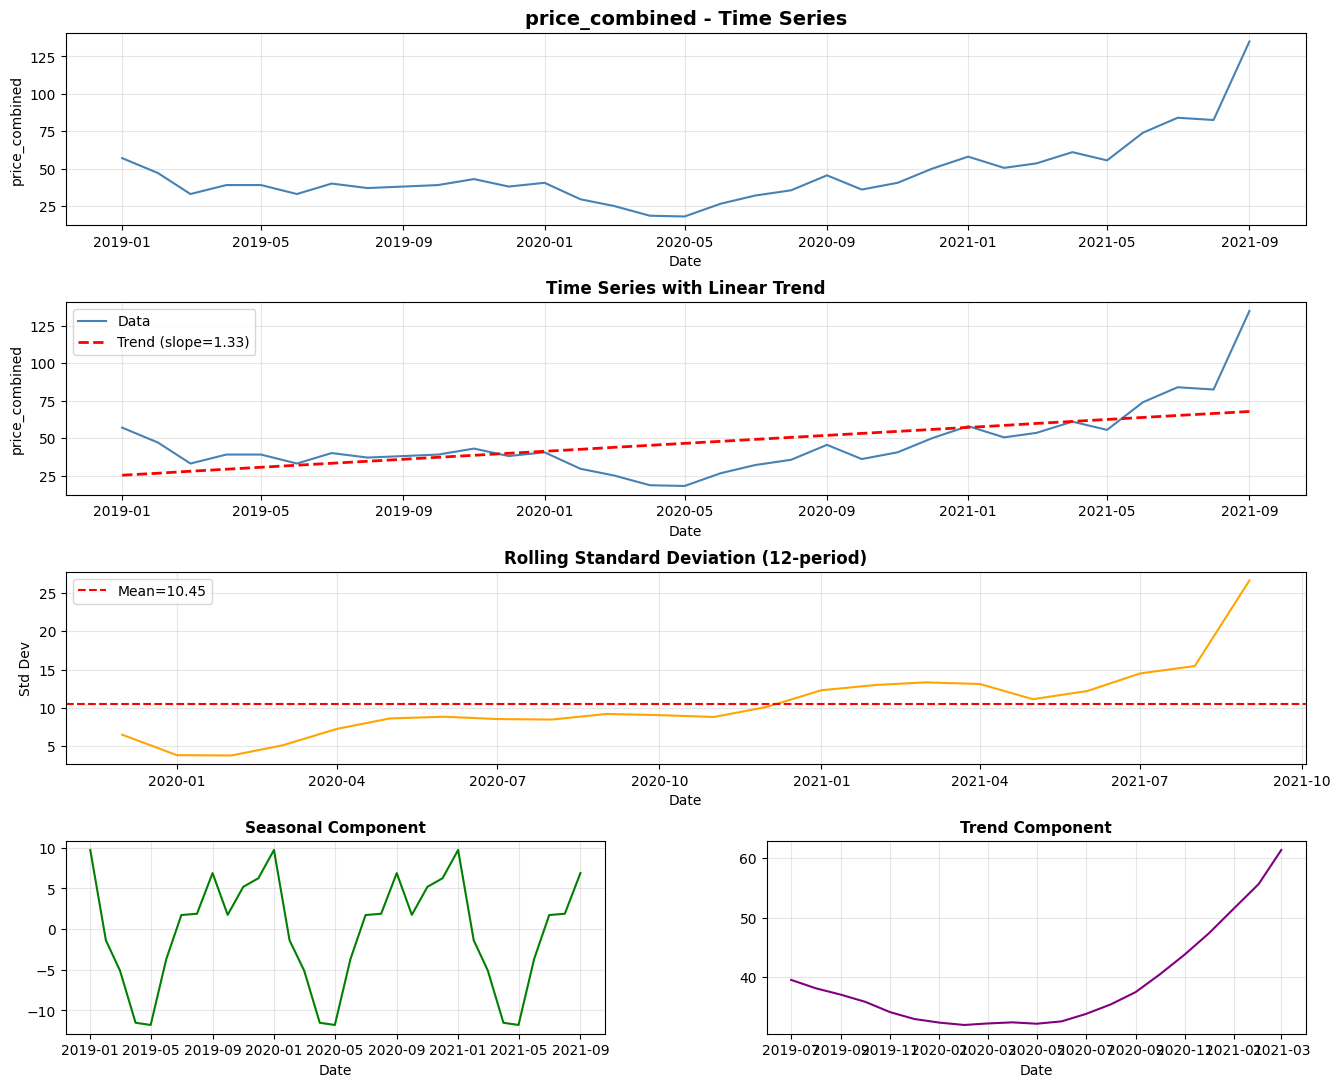

In [16]:

results = time_series_diagnostics(df_preshock, 'price_combined', aggregation_level='monthly')

TIME SERIES DIAGNOSTICS: price_combined
Aggregation Level: monthly
Period: 2021-09-01 00:00:00 to 2023-03-01 00:00:00
Observations: 19


STATIONARITY TESTS

Augmented Dickey-Fuller Test (H0: Unit root exists = Non-stationary):
  Test Statistic: -2.4792
  p-value: 0.1206
  Critical Values:
    1%: -3.8893
    5%: -3.0544
    10%: -2.6670
  → NON-STATIONARY (fail to reject H0, p=0.1206 >= 0.05)

KPSS Test (H0: Series is stationary):
  Test Statistic: 0.1491
  p-value: 0.0474
  Critical Values:
    10%: 0.1190
    5%: 0.1460
    2.5%: 0.1760
    1%: 0.2160
  → NON-STATIONARY (reject H0, p=0.0474 <= 0.05)

TREND ANALYSIS

Linear Trend:
  Slope: 0.7746 per period
  R-squared: 0.0020
  p-value: 0.8555
  → No significant trend (p=0.8555 >= 0.05)

VOLATILITY ANALYSIS

Overall Std Dev: 97.29
Mean Rolling Std (12-period): 105.13
Recent vs Early Volatility: +5.6%
  → Volatility is relatively STABLE

SEASONALITY ANALYSIS
  Seasonal decomposition skipped (insufficient data or wrong aggregation)

AU

ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 24 must be < 9.

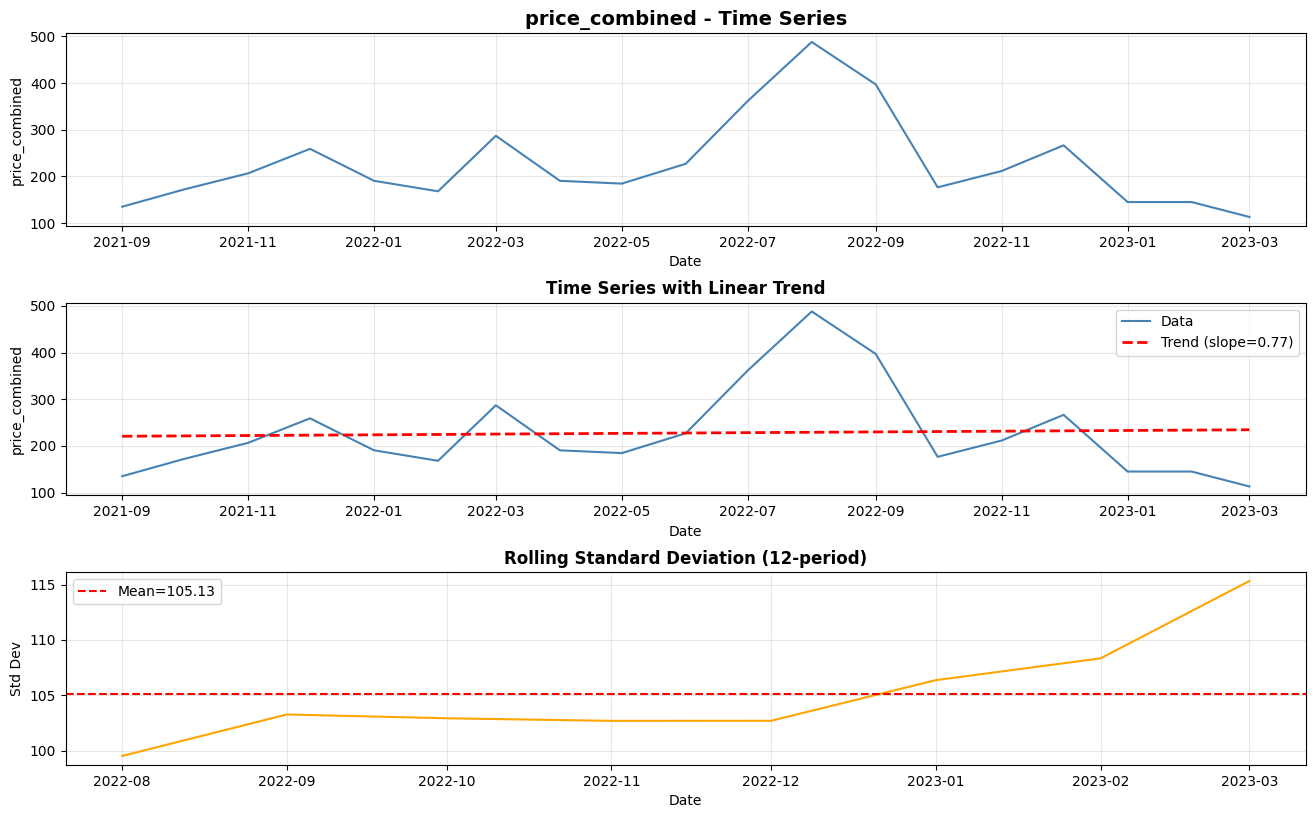

In [17]:
results = time_series_diagnostics(df_priceshock, 'price_combined', aggregation_level='monthly')